# MHIST Data Exploration

Explore the dataset, labels, and class distribution.

In [1]:
import os
import pandas as pd
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Define paths to the MHIST dataset

annotations_path = "../data/raw/annotations.csv"
images_path = "../data/raw/images/images"

# Load the annotation file
df = pd.read_csv(annotations_path)

print("Annotations loaded successfully!")
print("Number of rows:", len(df))
print("\nColumn names:")
print(df.columns.tolist())

Annotations loaded successfully!
Number of rows: 3152

Column names:
['Image Name', 'Majority Vote Label', 'Number of Annotators who Selected SSA (Out of 7)', 'Partition']


In [3]:
for i, column in enumerate(df.columns):
    print(i, "→", column)

0 → Image Name
1 → Majority Vote Label
2 → Number of Annotators who Selected SSA (Out of 7)
3 → Partition


In [4]:
print(df["Majority Vote Label"].value_counts())

Majority Vote Label
HP     2162
SSA     990
Name: count, dtype: int64


In [5]:
print(df["Partition"].value_counts())

Partition
train    2175
test      977
Name: count, dtype: int64


In [6]:
pd.crosstab(df["Partition"], df["Majority Vote Label"])

Majority Vote Label,HP,SSA
Partition,,
test,617,360
train,1545,630


In [7]:
agreement_counts = df["Number of Annotators who Selected SSA (Out of 7)"].value_counts().sort_index()

print(agreement_counts)


Number of Annotators who Selected SSA (Out of 7)
0    723
1    705
2    426
3    308
4    216
5    168
6    250
7    356
Name: count, dtype: int64


In [15]:
# Check the first image

first_image_name = df["Image Name"].iloc[0]
first_image_path = os.path.join(images_path, first_image_name)

img = Image.open(first_image_path)

print("Image name:", first_image_name)
print("Image size:", img.size)
print("Image mode:", img.mode)

Image name: MHIST_aaa.png
Image size: (224, 224)
Image mode: RGB


In [9]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nImages folder exists:")
print(os.path.exists(images_path))

print("\nImages path:")
print(os.path.abspath(images_path))

Current working directory:
c:\Users\hp\OneDrive\Desktop\MHIST-Research\Deep-learning-PBL-3\MHIST-Research\notebooks

Images folder exists:
True

Images path:
c:\Users\hp\OneDrive\Desktop\MHIST-Research\Deep-learning-PBL-3\MHIST-Research\data\raw\images


In [10]:
print("Filename from CSV:")
print(repr(first_image_name))

print("\nFull image path:")
print(repr(first_image_path))

print("\nDoes this exact file exist?")
print(os.path.exists(first_image_path))

Filename from CSV:
'MHIST_aaa.png'

Full image path:
'../data/raw/images\\MHIST_aaa.png'

Does this exact file exist?
False


In [11]:
import os

files = os.listdir(images_path)

print("Number of files in images folder:", len(files))
print("\nFirst 20 files:")
for file in files[:20]:
    print(repr(file))
    

Number of files in images folder: 1

First 20 files:
'images'


In [12]:
nested_images_path = os.path.join(images_path, "images")

print("Nested images folder exists:", os.path.exists(nested_images_path))

if os.path.exists(nested_images_path):
    files = os.listdir(nested_images_path)
    print("Number of files:", len(files))
    print("\nFirst 10 files:")
    for file in files[:10]:
        print(file)
        

Nested images folder exists: True
Number of files: 3152

First 10 files:
MHIST_aaa.png
MHIST_aab.png
MHIST_aac.png
MHIST_aad.png
MHIST_aae.png
MHIST_aaf.png
MHIST_aag.png
MHIST_aah.png
MHIST_aai.png
MHIST_aaj.png


In [16]:
import random

sample_names = random.sample(df["Image Name"].tolist(), 5)

for name in sample_names:
    path = os.path.join(images_path, name)
    
    with Image.open(path) as img:
        print(name, "→", img.size, "→", img.mode)

MHIST_eao.png → (224, 224) → RGB
MHIST_diw.png → (224, 224) → RGB
MHIST_cdf.png → (224, 224) → RGB
MHIST_bcm.png → (224, 224) → RGB
MHIST_dyg.png → (224, 224) → RGB


In [17]:
# Check whether every annotated image exists

missing_images = []

for name in df["Image Name"]:
    image_path = os.path.join(images_path, name)
    
    if not os.path.exists(image_path):
        missing_images.append(name)

print("Total annotated images:", len(df))
print("Missing images:", len(missing_images))

if len(missing_images) > 0:
    print("\nMissing image names:")
    print(missing_images[:20])
else:
    print("All annotated images are present! ✅")

Total annotated images: 3152
Missing images: 0
All annotated images are present! ✅


In [18]:
# Check for duplicate image names

duplicate_count = df["Image Name"].duplicated().sum()

print("Duplicate image entries:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate image names found! ✅")
else:
    print("Duplicate entries found. ⚠️")
    

Duplicate image entries: 0
No duplicate image names found! ✅


In [19]:
# Check for missing values

print(df.isnull().sum())

Image Name                                          0
Majority Vote Label                                 0
Number of Annotators who Selected SSA (Out of 7)    0
Partition                                           0
dtype: int64


In [20]:
print("Unique class labels:")
print(df["Majority Vote Label"].unique())

print("\nUnique partitions:")
print(df["Partition"].unique())

Unique class labels:
<StringArray>
['SSA', 'HP']
Length: 2, dtype: str

Unique partitions:
<StringArray>
['train', 'test']
Length: 2, dtype: str


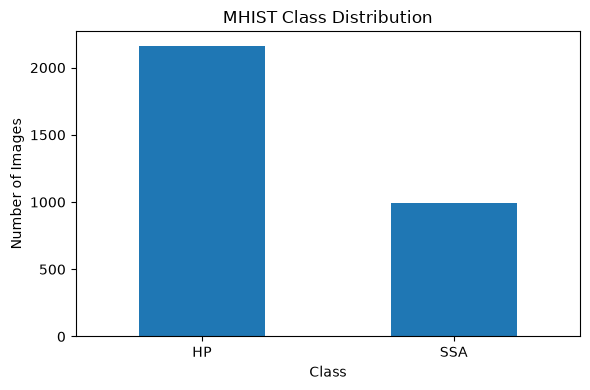

In [21]:
import matplotlib.pyplot as plt

class_counts = df["Majority Vote Label"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("MHIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

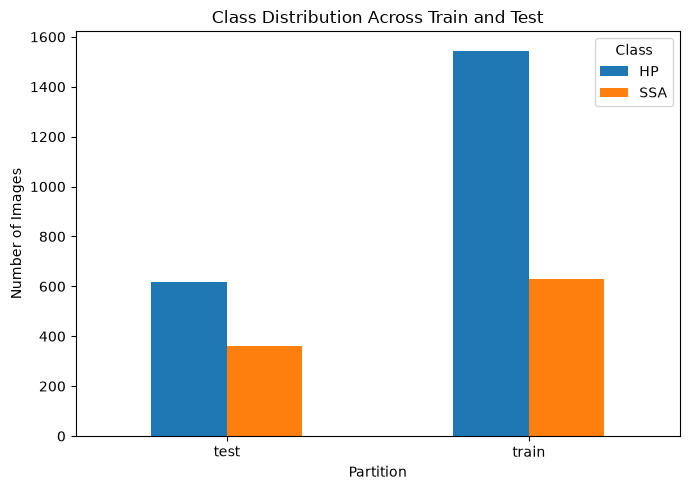

In [22]:
partition_class_counts = pd.crosstab(
    df["Partition"],
    df["Majority Vote Label"]
)

partition_class_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Class Distribution Across Train and Test")
plt.xlabel("Partition")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

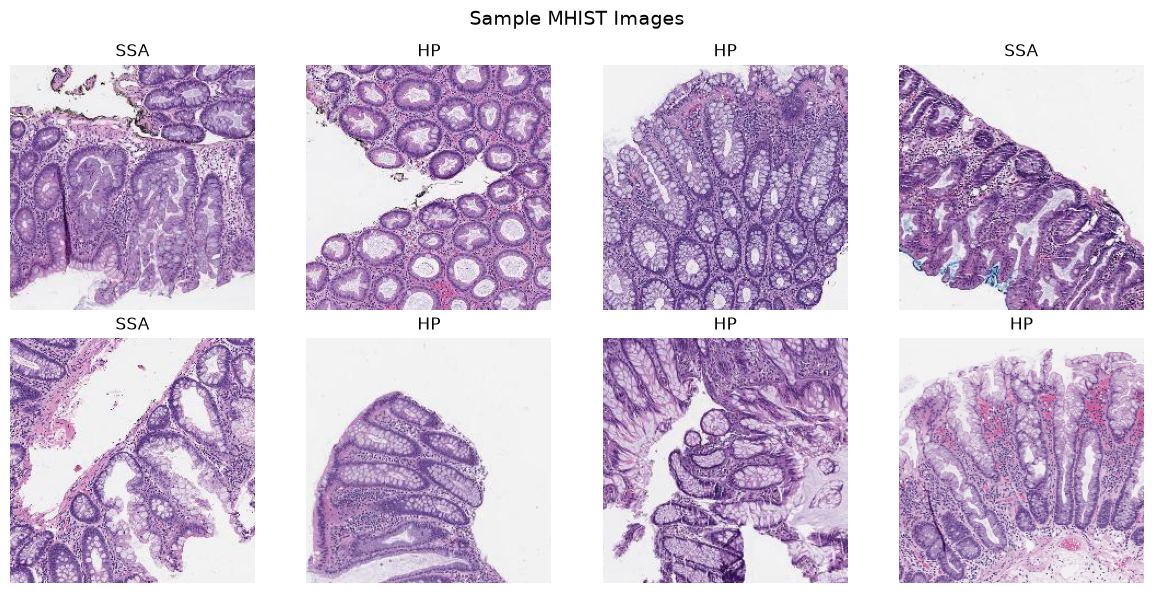

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

sample_df = df.sample(8, random_state=42)

for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    image_path = os.path.join(images_path, row["Image Name"])
    
    img = Image.open(image_path)
    
    ax.imshow(img)
    ax.set_title(row["Majority Vote Label"])
    ax.axis("off")

plt.suptitle("Sample MHIST Images", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

sample_names = df["Image Name"].sample(5, random_state=42)

for name in sample_names:
    image_path = os.path.join(images_path, name)
    
    img = np.array(Image.open(image_path))
    
    print(
        name,
        "→ min:", img.min(),
        "max:", img.max(),
        "mean:", round(img.mean(), 2)
    )

MHIST_blw.png → min: 0 max: 255 mean: 172.09
MHIST_dou.png → min: 0 max: 255 mean: 177.7
MHIST_eoz.png → min: 0 max: 255 mean: 163.41
MHIST_cor.png → min: 0 max: 255 mean: 183.68
MHIST_ecj.png → min: 0 max: 255 mean: 191.41
